<a href="https://colab.research.google.com/github/Shajjad-142/AI-research/blob/main/work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

# 1. Mount your Google Drive
# Follow the instructions in the output (click link, allow access, paste verification code)
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import os

# Define the path to your CSV file on Google Drive
# IMPORTANT: Adjust the 'Your_Folder_Path' and 'your_data.csv' parts
# Example: '/content/drive/MyDrive/DataScience_Projects/sales_data.csv'
FILE_PATH = '/content/drive/MyDrive/My Project/credit_card_transactions.csv'

# Check if the file exists before trying to read it
if os.path.exists(FILE_PATH):
    # Load the CSV data into a Pandas DataFrame
    df = pd.read_csv(FILE_PATH)

    print(f"\nSuccessfully loaded data from Google Drive.")
    print("--- Head of the DataFrame ---")
    print(df.head())
else:
    print(f"\nError: File not found at the path: {FILE_PATH}")
    print("Please check the path and make sure your Google Drive is mounted correctly.")


Successfully loaded data from Google Drive.
--- Head of the DataFrame ---
  trans_date_trans_time        cc_num                            merchant  \
0      01-01-2019 00:00  2.703190e+15          fraud_Rippin, Kub and Mann   
1      01-01-2019 00:00  6.304230e+11     fraud_Heller, Gutmann and Zieme   
2      01-01-2019 00:00  3.885950e+13                fraud_Lind-Buckridge   
3      01-01-2019 00:01  3.534090e+15  fraud_Kutch, Hermiston and Farrell   
4      01-01-2019 00:03  3.755340e+14                 fraud_Keeling-Crist   

        category     amt      first     last gender  \
0       misc_net    4.97   Jennifer    Banks      F   
1    grocery_pos  107.23  Stephanie     Gill      F   
2  entertainment  220.11     Edward  Sanchez      M   
3  gas_transport   45.00     Jeremy    White      M   
4       misc_pos   41.96      Tyler   Garcia      M   

                         street            city  ...      long  city_pop  \
0                561 Perry Cove  Moravian Falls  ...  -

In [15]:
# Cell 1 - Imports & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
import joblib
from scipy.stats import randint as sp_randint, uniform as sp_uniform

import warnings
warnings.filterwarnings("ignore")

plt.style.use('seaborn-v0_8')
sns.set_palette("Set2")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tqdm.pandas()  # enable tqdm progress bars for pandas

In [16]:
# Cell 2 - Load Dataset
import kagglehub
dataset_path = kagglehub.dataset_download('aicrdghj/credit-card-fraud-detection-dataset')
CSV_PATH = dataset_path + "/credit_card_transactions.csv"

df = pd.read_csv(CSV_PATH)
print("✅ Dataset Loaded Successfully!")
print("Shape:", df.shape)
df.head()

100%|██████████| 108M/108M [00:04<00:00, 24.7MB/s]

Extracting files...


✅ Dataset Loaded Successfully!
Shape: (1048575, 23)


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,01-01-2019 00:00,2.703190e+15,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,-81.1781,3495,"Psychologist, counselling",09-03-1988,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0
1,01-01-2019 00:00,6.304230e+11,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,-118.2105,149,Special educational needs teacher,21-06-1978,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN
2,01-01-2019 00:00,3.885950e+13,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,-112.2620,4154,Nature conservation officer,19-01-1962,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0
3,01-01-2019 00:01,3.534090e+15,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,-112.1138,1939,Patent attorney,12-01-1967,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN
4,01-01-2019 00:03,3.755340e+14,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,-79.4629,99,Dance movement psychotherapist,28-03-1986,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1048575 non-null  object 
 1   cc_num                 1048575 non-null  float64
 2   merchant               1048575 non-null  object 
 3   category               1048575 non-null  object 
 4   amt                    1048575 non-null  float64
 5   first                  1048575 non-null  object 
 6   last                   1048575 non-null  object 
 7   gender                 1048575 non-null  object 
 8   street                 1048575 non-null  object 
 9   city                   1048575 non-null  object 
 10  state                  1048575 non-null  object 
 11  zip                    1048575 non-null  int64  
 12  lat                    1048575 non-null  float64
 13  long                   1048575 non-null  float64
 14  city_p

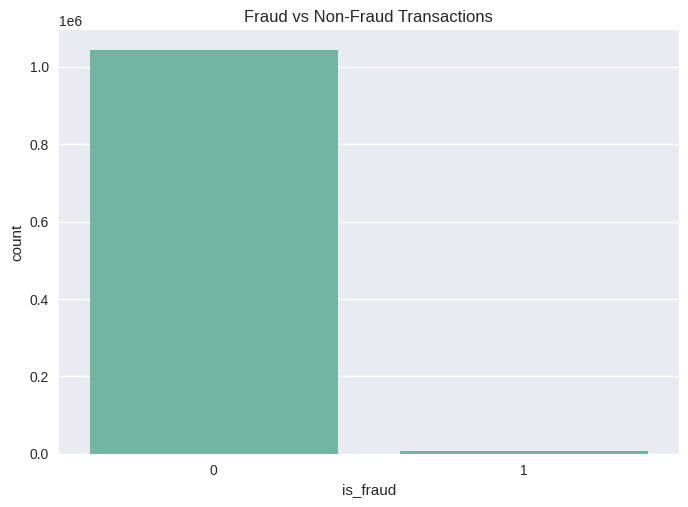

Fraud Percentage: 0.57%


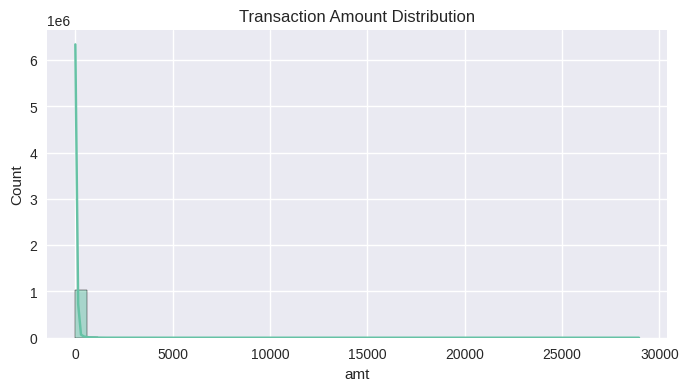

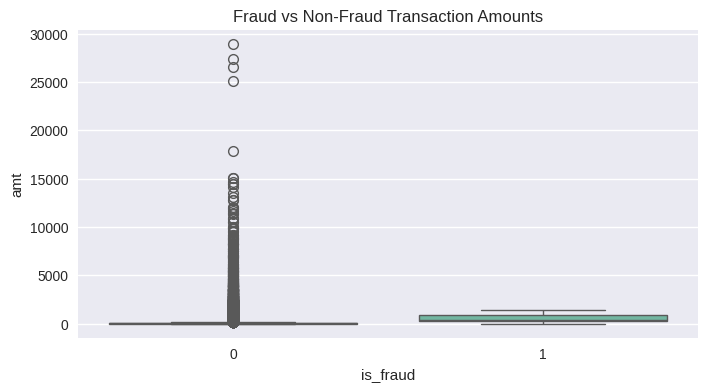

In [17]:
# Cell 3 - Explore Dataset
print("\nData Info:")
print(df.info())

print("\nMissing Values:\n", df.isnull().sum())

# Fraud Distribution
sns.countplot(x='is_fraud', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

fraud_ratio = df['is_fraud'].value_counts(normalize=True) * 100
print(f"Fraud Percentage: {fraud_ratio[1]:.2f}%")

# Amount Distribution
plt.figure(figsize=(8,4))
sns.histplot(df['amt'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

# Fraud Amount Comparison
plt.figure(figsize=(8,4))
sns.boxplot(x='is_fraud', y='amt', data=df)
plt.title("Fraud vs Non-Fraud Transaction Amounts")
plt.show()

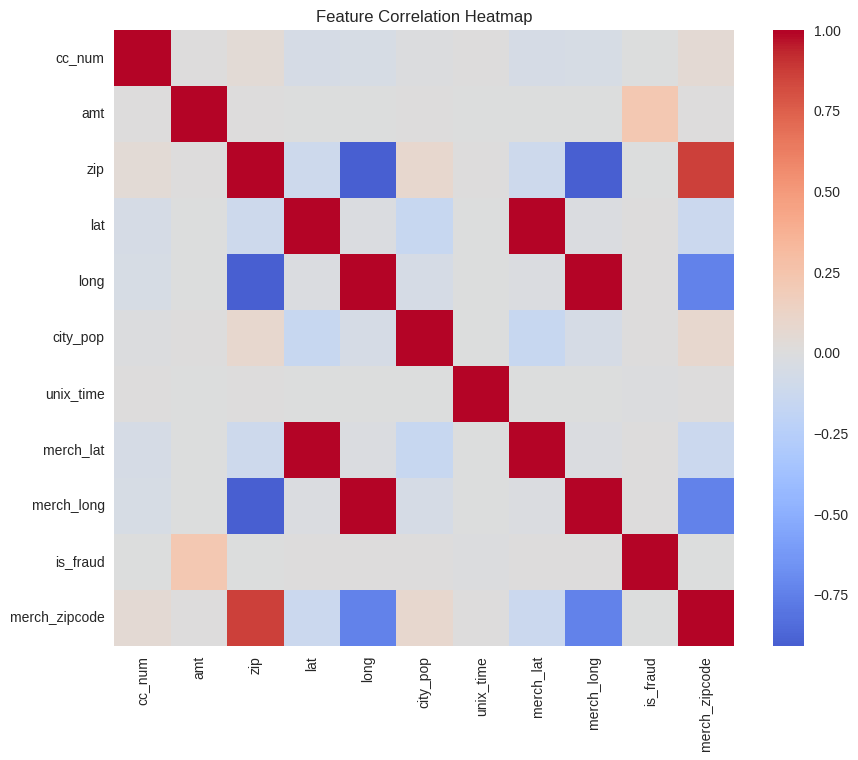

✅ Missing values handled successfully.


In [18]:
# Cell 4 - Handle Missing Values
if 'merch_zipcode' in df.columns:
    df['merch_zipcode'].fillna(df['merch_zipcode'].mode()[0], inplace=True)

# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

print("✅ Missing values handled successfully.")

In [19]:
# Cell 5 - Feature Engineering
with tqdm(total=6, desc="Feature Engineering") as pbar:
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'], errors='coerce'); pbar.update(1)
    df['dob'] = pd.to_datetime(df['dob'], errors='coerce'); pbar.update(1)

    df['trans_year'] = df['trans_date_trans_time'].dt.year
    df['trans_month'] = df['trans_date_trans_time'].dt.month
    df['trans_day'] = df['trans_date_trans_time'].dt.day
    df['trans_hour'] = df['trans_date_trans_time'].dt.hour
    df['trans_weekday'] = df['trans_date_trans_time'].dt.weekday; pbar.update(1)

    df['age'] = ((df['trans_date_trans_time'] - df['dob']).dt.days // 365).fillna(0).astype(int)
    df['age'] = df['age'].clip(lower=0, upper=120); pbar.update(1)

    drop_cols = ['trans_date_trans_time', 'dob', 'cc_num', 'first', 'last', 'street', 'trans_num']
    df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True); pbar.update(2)

print("✅ Feature engineering done. Shape:", df.shape)

Feature Engineering:   0%|          | 0/6 [00:00<?, ?it/s]

✅ Feature engineering done. Shape: (1048575, 22)


In [20]:
# Cell 6 - Frequency Encoding with tqdm
cat_cols = [c for c in ['merchant', 'category', 'gender', 'city', 'state', 'job'] if c in df.columns]

for col in tqdm(cat_cols, desc="Frequency Encoding"):
    freq = df[col].value_counts(normalize=True)
    df[f"{col}_freq"] = df[col].map(freq)
    df.drop(columns=col, inplace=True)

print("✅ Categorical encoding complete. Shape:", df.shape)

Frequency Encoding:   0%|          | 0/6 [00:00<?, ?it/s]

✅ Categorical encoding complete. Shape: (1048575, 22)


In [21]:
# Cell 7 - Prepare Features and Target
TARGET = 'is_fraud'
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

print("Feature count:", X.shape[1])
print("Target distribution:\n", y.value_counts())

Feature count: 21
Target distribution:
 is_fraud
0    1042569
1       6006
Name: count, dtype: int64


In [22]:
# Cell 8 - Train/Test Split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("✅ Train/Test Split Complete")
print("Train:", X_train_raw.shape, "Test:", X_test_raw.shape)

✅ Train/Test Split Complete
Train: (838860, 21) Test: (209715, 21)


In [23]:
# Cell 9 - Scaling + SMOTE with tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from tqdm.auto import tqdm
import numpy as np

# 1️⃣ Identify numeric and categorical columns
num_cols = X_train_raw.select_dtypes(include=np.number).columns
cat_cols = X_train_raw.select_dtypes(exclude=np.number).columns

# 2️⃣ Impute missing values
# Numeric: median, Categorical: most frequent
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

X_train_raw[num_cols] = num_imputer.fit_transform(X_train_raw[num_cols])
X_test_raw[num_cols] = num_imputer.transform(X_test_raw[num_cols])

if len(cat_cols) > 0:
    X_train_raw[cat_cols] = cat_imputer.fit_transform(X_train_raw[cat_cols])
    X_test_raw[cat_cols] = cat_imputer.transform(X_test_raw[cat_cols])

# 3️⃣ Scaling numeric features
scaler = StandardScaler()
X_train_scaled = X_train_raw.copy()
X_test_scaled = X_test_raw.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train_scaled[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test_scaled[num_cols])

# 4️⃣ Apply SMOTE to balance classes
sm = SMOTE(random_state=RANDOM_STATE)

with tqdm(total=1, desc="Applying SMOTE") as pbar:
    X_train_bal, y_train_bal = sm.fit_resample(X_train_scaled, y_train)
    pbar.update(1)

# 5️⃣ Summary
print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_train_bal))
print("✅ Scaling + SMOTE complete. Shape of balanced X_train:", X_train_bal.shape)

Applying SMOTE:   0%|          | 0/1 [00:00<?, ?it/s]

Before SMOTE: [834055   4805]
After SMOTE: [834055 834055]
✅ Scaling + SMOTE complete. Shape of balanced X_train: (1668110, 21)


In [24]:
# Cell 10 - Model Training and Selection (This is the missing step)

# Define the LightGBM model
lgbm = LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1)

# Define a hyperparameter search space
param_dist = {
    'n_estimators': sp_randint(100, 500),
    'learning_rate': sp_uniform(0.01, 0.15),
    'num_leaves': sp_randint(20, 40),
    'max_depth': sp_randint(5, 10),
    'min_child_samples': sp_randint(20, 100),
    'subsample': sp_uniform(0.6, 0.4),
    'colsample_bytree': sp_uniform(0.6, 0.4),
    'reg_alpha': sp_uniform(0, 0.5),
    'reg_lambda': sp_uniform(0, 0.5)
}

# Setup Randomized Search (Using a small n_iter for a quick example)
# Note: Use the SMOTE-balanced data (X_train_bal, y_train_bal)
random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=10,  # Increase this for better results (e.g., 50 or 100)
    scoring='roc_auc',
    cv=3,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Use tqdm to show progress of the entire search
# with tqdm(total=random_search.n_iter, desc="Randomized Search") as pbar:
#     def callback(estimator, cv_results_):
#         pbar.update(1)

    # Train the model using the balanced dataset
    # The 'fit' step will execute the hyperparameter search
random_search.fit(X_train_bal, y_train_bal)

# Assign the best performing model to the variable 'best_model'
# This variable is what Cell 11 is looking for!
best_model = random_search.best_estimator_

print("\nBest Model Found:")
print(best_model)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Info] Number of positive: 834055, number of negative: 834055
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.383043 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5101
[LightGBM] [Info] Number of data points in the train set: 1668110, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

Best Model Found:
LGBMClassifier(colsample_bytree=np.float64(0.6053059844639466),
               learning_rate=np.float64(0.15133026335272792), max_depth=6,
               min_child_samples=28, n_estimators=445, n_jobs=-1, num_leaves=21,
               random_state=42, 


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    208514
           1       0.71      0.85      0.77      1201

    accuracy                           1.00    209715
   macro avg       0.85      0.92      0.88    209715
weighted avg       1.00      1.00      1.00    209715

ROC-AUC: 0.9961182638269548


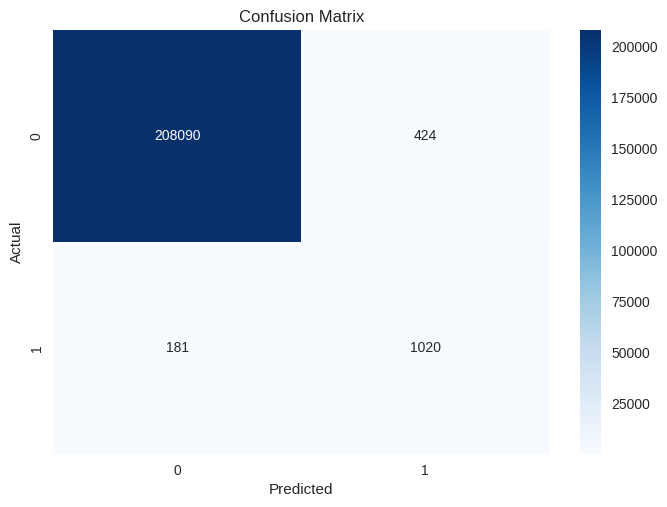

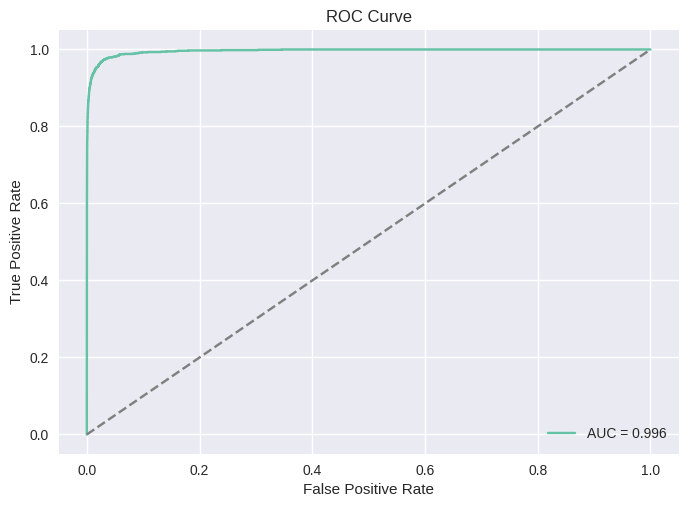

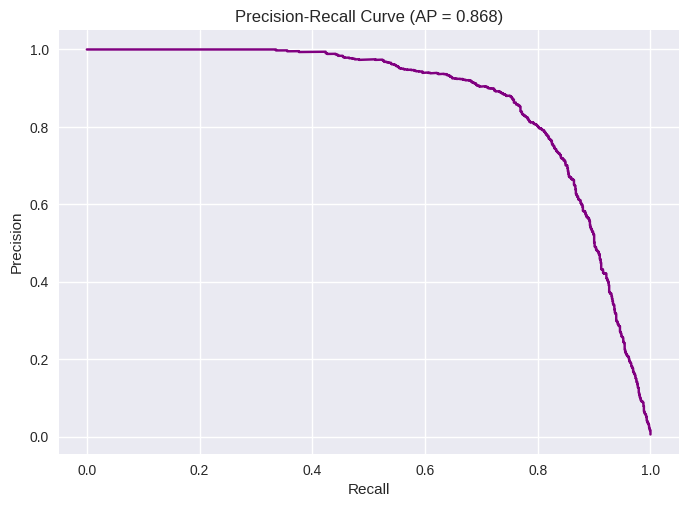

In [25]:
# Cell 11 - Evaluate Model
y_pred = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, y_proba)
plt.plot(rec, prec, color='purple')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AP = {average_precision_score(y_test, y_proba):.3f})")
plt.show()

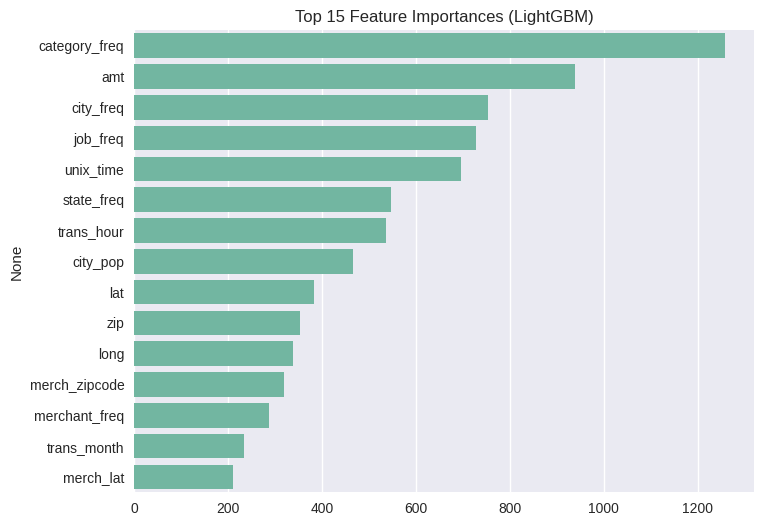

In [26]:

# Cell 12 - Feature Importance
importances = pd.Series(best_model.feature_importances_, index=X.columns)
top_features = importances.nlargest(15)

plt.figure(figsize=(8,6))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title("Top 15 Feature Importances (LightGBM)")
plt.show()

In [27]:
from sklearn.metrics import f1_score
import numpy as np

# Probabilities for the positive class
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# Test thresholds from 0.01 to 0.99
thresholds = np.arange(0.01, 1.0, 0.01)
f1_scores = []

for t in thresholds:
    y_pred_thresh = (y_proba >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_thresh))

# Find threshold that gives max F1
best_thresh = thresholds[np.argmax(f1_scores)]
print(f"✅ Optimal threshold for max F1: {best_thresh:.2f}")
print(f"Max F1-score: {max(f1_scores):.3f}")

✅ Optimal threshold for max F1: 0.88
Max F1-score: 0.811



Classification Report (Optimized Threshold):

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    208514
           1       0.88      0.75      0.81      1201

    accuracy                           1.00    209715
   macro avg       0.94      0.88      0.90    209715
weighted avg       1.00      1.00      1.00    209715



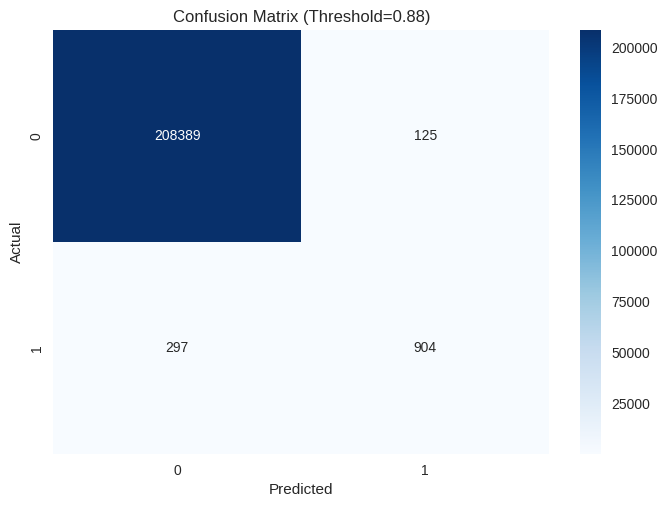

In [28]:
# Predictions using the new threshold
y_pred_opt = (y_proba >= best_thresh).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print("\nClassification Report (Optimized Threshold):\n")
print(classification_report(y_test, y_pred_opt))

# Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix (Threshold={best_thresh:.2f})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

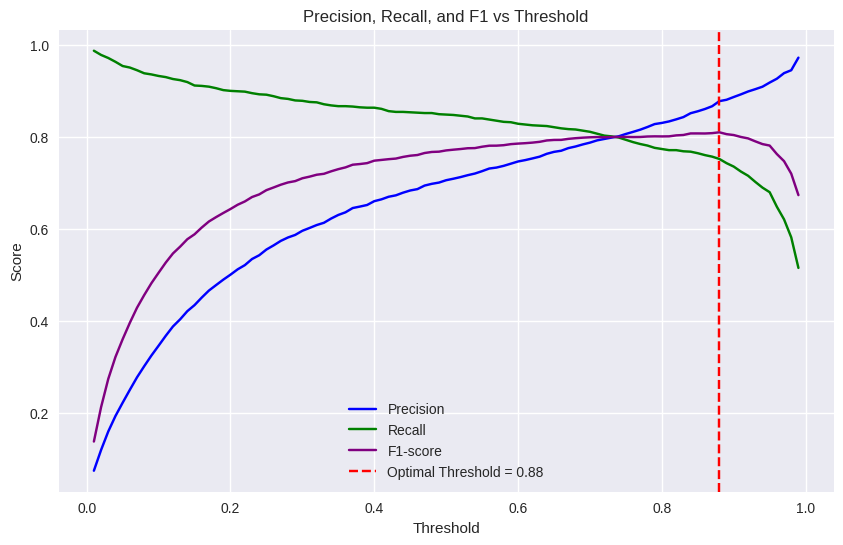

In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

# Probabilities for the positive class
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# Thresholds to evaluate
thresholds = np.arange(0.01, 1.0, 0.01)
precisions = []
recalls = []
f1_scores = []

for t in thresholds:
    y_pred_thresh = (y_proba >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_thresh))
    recalls.append(recall_score(y_test, y_pred_thresh))
    f1_scores.append(f1_score(y_test, y_pred_thresh))

# Plot
plt.figure(figsize=(10,6))
plt.plot(thresholds, precisions, label='Precision', color='blue')
plt.plot(thresholds, recalls, label='Recall', color='green')
plt.plot(thresholds, f1_scores, label='F1-score', color='purple')
plt.axvline(best_thresh, color='red', linestyle='--', label=f'Optimal Threshold = {best_thresh:.2f}')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
# Cell — Print scores at optimal threshold
y_pred_opt = (y_proba >= best_thresh).astype(int)

prec = precision_score(y_test, y_pred_opt)
rec = recall_score(y_test, y_pred_opt)
f1 = f1_score(y_test, y_pred_opt)

print(f"Scores at Optimal Threshold = {best_thresh:.2f}:")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1-score:  {f1:.3f}")

Scores at Optimal Threshold = 0.88:
Precision: 0.879
Recall:    0.753
F1-score:  0.811


Fraud rate by category:
 category_freq
0.075244    0.017427
0.048716    0.014526
0.095278    0.013973
0.089982    0.007016
0.101500    0.004679
0.031309    0.003046
0.061504    0.003008
0.035018    0.002996
0.072461    0.002435
0.070093    0.002340
0.087170    0.002122
0.070611    0.001634
0.094965    0.001536
0.066149    0.001499
Name: is_fraud, dtype: float64


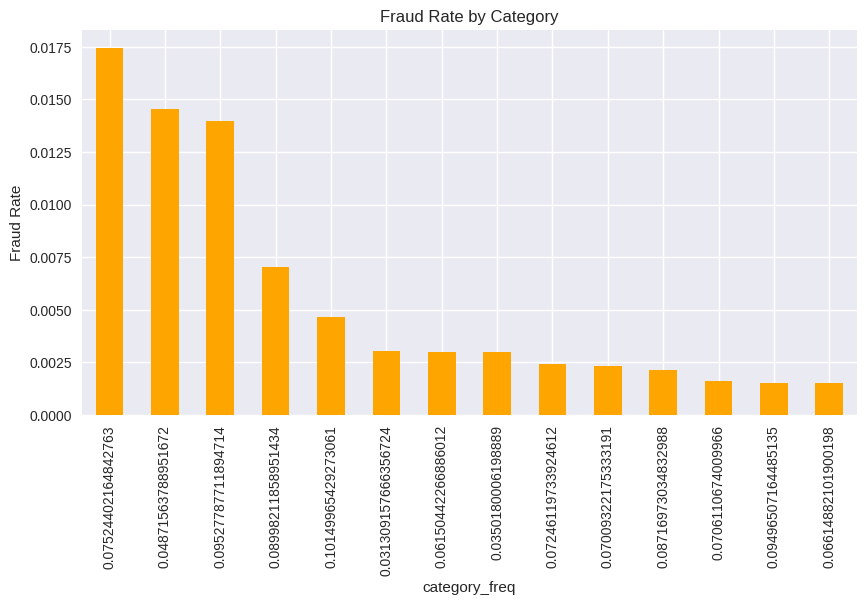

In [31]:
# Fraud rate per category
if 'category_freq' in df.columns:  # use encoded category if available
    category_col = 'category_freq'
else:
    category_col = 'category'

fraud_by_category = df.groupby(category_col)['is_fraud'].mean().sort_values(ascending=False)
print("Fraud rate by category:\n", fraud_by_category)

# Plot
plt.figure(figsize=(10,5))
fraud_by_category.plot(kind='bar', color='orange')
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Category")
plt.show()

Top 20 high-risk merchants:
 merchant_freq
0.000978    0.027290
0.001519    0.021971
0.001475    0.021332
0.001525    0.021263
0.001532    0.021171
0.001501    0.020966
0.001571    0.020644
0.000971    0.020629
0.001866    0.020439
0.001510    0.020215
0.000991    0.020212
0.001526    0.020000
0.001543    0.019778
0.001498    0.019733
0.001512    0.019558
0.000979    0.019474
0.001916    0.019413
0.001539    0.019207
0.000897    0.019129
0.001507    0.018987
Name: is_fraud, dtype: float64


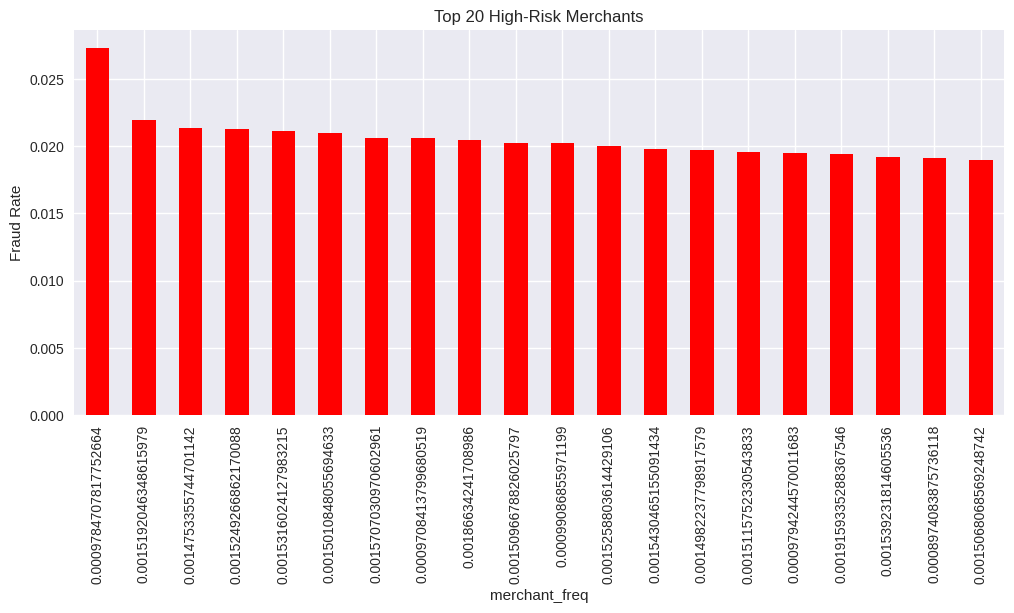

In [32]:
if 'merchant_freq' in df.columns:
    merchant_col = 'merchant_freq'
else:
    merchant_col = 'merchant'

fraud_by_merchant = df.groupby(merchant_col)['is_fraud'].mean().sort_values(ascending=False).head(20)  # top 20 risky merchants
print("Top 20 high-risk merchants:\n", fraud_by_merchant)

# Plot
plt.figure(figsize=(12,5))
fraud_by_merchant.plot(kind='bar', color='red')
plt.ylabel("Fraud Rate")
plt.title("Top 20 High-Risk Merchants")
plt.show()

Fraud rate by transaction amount:
 amt_bin
0-50         0.002381
50-100       0.000121
100-500      0.009940
500-1000     0.227843
1000-5000    0.250897
5000+        0.000000
Name: is_fraud, dtype: float64


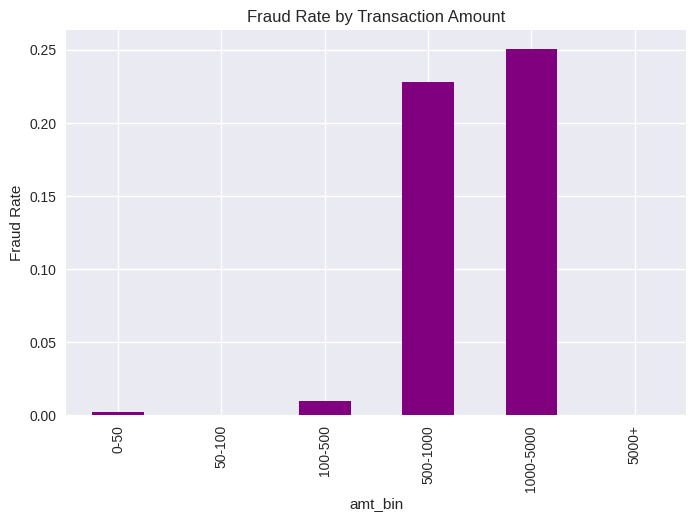

In [33]:
# Create amount bins
bins = [0, 50, 100, 500, 1000, 5000, df['amt'].max()]
labels = ["0-50","50-100","100-500","500-1000","1000-5000","5000+"]
df['amt_bin'] = pd.cut(df['amt'], bins=bins, labels=labels)

fraud_by_amount = df.groupby('amt_bin')['is_fraud'].mean()
print("Fraud rate by transaction amount:\n", fraud_by_amount)

# Plot
plt.figure(figsize=(8,5))
fraud_by_amount.plot(kind='bar', color='purple')
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Transaction Amount")
plt.show()

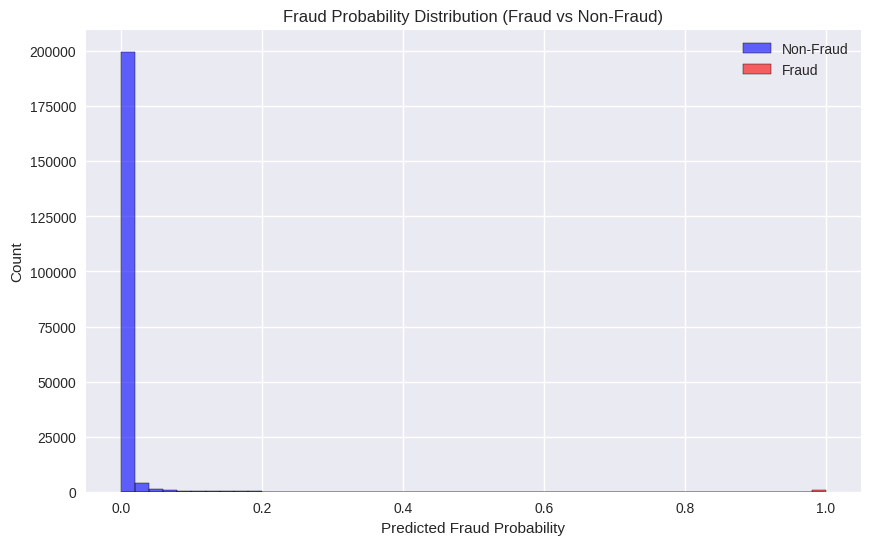

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Predicted probabilities
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# Create a DataFrame for plotting
prob_df = pd.DataFrame({
    'y_true': y_test,
    'fraud_proba': y_proba
})

plt.figure(figsize=(10,6))
sns.histplot(prob_df[prob_df['y_true']==0]['fraud_proba'], bins=50, color='blue', label='Non-Fraud', alpha=0.6)
sns.histplot(prob_df[prob_df['y_true']==1]['fraud_proba'], bins=50, color='red', label='Fraud', alpha=0.6)
plt.xlabel("Predicted Fraud Probability")
plt.ylabel("Count")
plt.title("Fraud Probability Distribution (Fraud vs Non-Fraud)")
plt.legend()
plt.show()

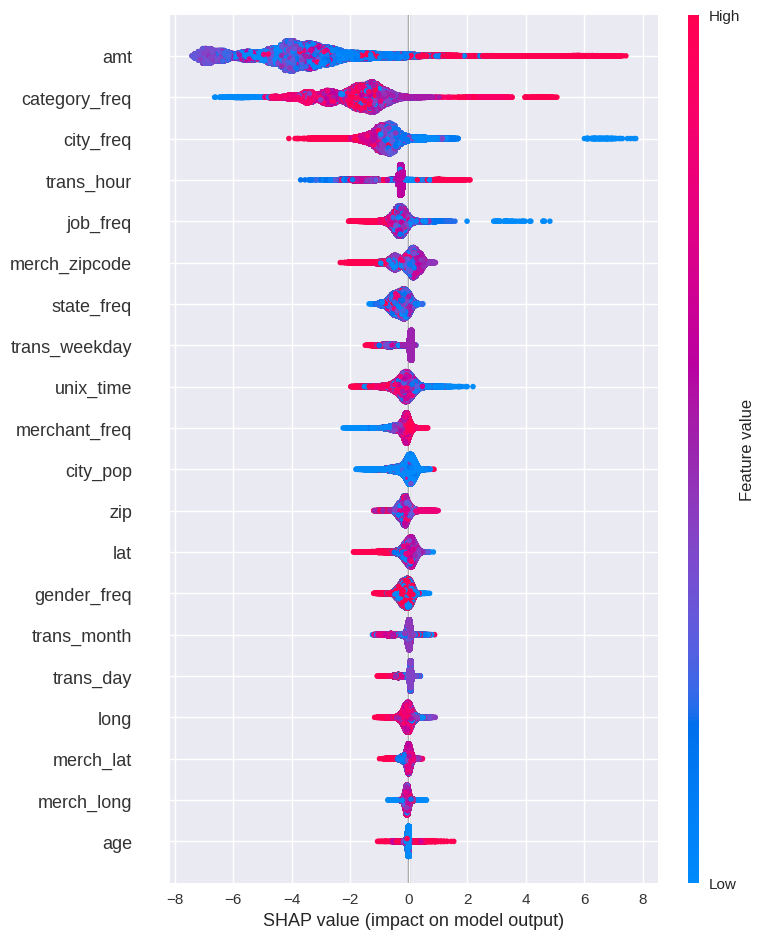

In [37]:
import shap
import pandas as pd

# Convert scaled array back to DataFrame for SHAP
# Assuming X_test_scaled and X.columns are available from previous cells
X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# Create SHAP explainer
explainer = shap.TreeExplainer(best_model)

# --- CORRECTION 1: Check the shape of the output ---
# Run this line first and check the shape.
# If it is (N_samples, N_features), do not index it.
# If it is a list of two (N_samples, N_features) matrices, then index it as [1].
raw_shap_values = explainer.shap_values(X_test_df)

# Check the type and shape:
# If type(raw_shap_values) is a list (most common for binary), use:
if isinstance(raw_shap_values, list):
    # This is the SHAP value matrix for the POSITIVE CLASS (index 1)
    shap_values_matrix = raw_shap_values[1]
else:
    # This is already a 2D matrix (less common, but matches your error)
    shap_values_matrix = raw_shap_values


# --- CORRECTION 2: Use the 2D matrix for the Summary Plot ---
# Global summary plot
# Pass the correct 2D SHAP values matrix
shap.summary_plot(shap_values_matrix, X_test_df)


# --- CORRECTION 3: Use the 2D matrix for the Force Plot ---
# Local explanation for the first transaction
idx = 0
# Pass the correct expected value and SHAP values for the selected instance
# You still need to index the expected_value and the shap_values for the instance
expected_value_for_plot = explainer.expected_value
if isinstance(expected_value_for_plot, list):
    expected_value_for_plot = expected_value_for_plot[1] # Expected value for positive class

shap.force_plot(
    expected_value_for_plot,
    shap_values_matrix[idx, :], # Use the 2D matrix and index a single row (vector)
    X_test_df.iloc[idx]
)

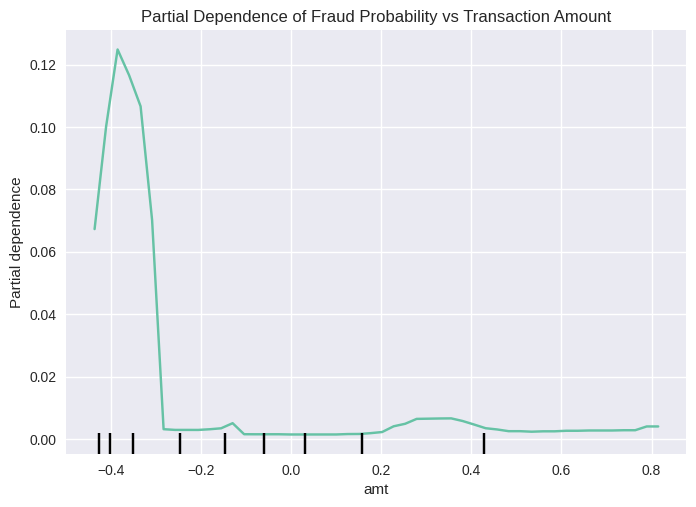

In [38]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Transaction amount partial dependence
feature_idx = X.columns.get_loc('amt')  # index of 'amt' column

PartialDependenceDisplay.from_estimator(
    best_model,
    X_test_scaled,
    features=[feature_idx],
    feature_names=X.columns,
    kind="average",  # "average" for PDP
    grid_resolution=50
)
plt.title("Partial Dependence of Fraud Probability vs Transaction Amount")
plt.show()